<a href="https://colab.research.google.com/github/tanishque-suthar/dl-miniproject/blob/main/dl_minip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

# Install kaggle
!pip install kaggle --quiet

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download -d protobioengineering/mit-bih-arrhythmia-database-modern-2023
!unzip -q mit-bih-arrhythmia-database-modern-2023.zip -d ./mitbih_csv
!ls ./mitbih_csv   # check the folder structure

Dataset URL: https://www.kaggle.com/datasets/protobioengineering/mit-bih-arrhythmia-database-modern-2023
License(s): CC-BY-SA-4.0
100% 231M/231M [00:06<00:00, 34.6MB/s]

100_annotations_1.csv	117_ekg.csv		212_ekg.csv
100_annotations_1.json	117_ekg.json		212_ekg.json
100_ekg.csv		118_annotations_1.csv	213_annotations_1.csv
100_ekg.json		118_annotations_1.json	213_annotations_1.json
101_annotations_1.csv	118_ekg.csv		213_ekg.csv
101_annotations_1.json	118_ekg.json		213_ekg.json
101_ekg.csv		119_annotations_1.csv	214_annotations_1.csv
101_ekg.json		119_annotations_1.json	214_annotations_1.json
102_annotations_1.csv	119_annotations_2.csv	214_annotations_2.csv
102_annotations_1.json	119_ekg.csv		214_ekg.csv
102_ekg.csv		119_ekg.json		214_ekg.json
102_ekg.json		121_annotations_1.csv	215_annotations_1.csv
103_annotations_1.csv	121_annotations_1.json	215_annotations_1.json
103_annotations_1.json	121_ekg.csv		215_annotations_2.csv
103_ekg.csv		121_ekg.json		215_ekg.csv
103_ekg.json		122_annotat

In [3]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict

data_dir = './mitbih_csv'

# ── Peek at one EKG file ─────────────────────────────────
df_sig = pd.read_csv(os.path.join(data_dir, '100_ekg.csv'))
print("=== EKG CSV columns:", df_sig.columns.tolist())
print(df_sig.head(3))
print("Shape:", df_sig.shape)

# ── Peek at one annotation file ──────────────────────────
df_ann = pd.read_csv(os.path.join(data_dir, '100_annotations_1.csv'))
print("\n=== Annotation CSV columns:", df_ann.columns.tolist())
print(df_ann.head(10))

# ── Check the annotation symbols reference ───────────────
df_sym = pd.read_csv(os.path.join(data_dir, 'annotation_symbols.csv'))
print("\n=== Annotation Symbols:")
print(df_sym)

=== EKG CSV columns: ['Unnamed: 0', 'MLII', 'V5', 'symbol']
   Unnamed: 0   MLII     V5 symbol
0           0 -0.145 -0.065    NaN
1           1 -0.145 -0.065    NaN
2           2 -0.145 -0.065    NaN
Shape: (650000, 4)

=== Annotation CSV columns: ['index', 'annotation_symbol']
   index annotation_symbol
0     18                 +
1     77                 N
2    370                 N
3    662                 N
4    946                 N
5   1231                 N
6   1515                 N
7   1809                 N
8   2044                 A
9   2402                 N

=== Annotation Symbols:
                                                                       symbol  \
·     Normal beat (displayed as "·" by the PhysioBank...  LightWAVE   pschart   
N     Normal beat                                        NaN              NaN   
L     Left bundle branch block beat                      NaN              NaN   
R     Right bundle branch block beat                     NaN              N

In [4]:
import json
with open('./mitbih_csv/100_ekg.json') as f:
    d = json.load(f)
print(type(d))
print(list(d.keys()) if isinstance(d, dict) else d[:2])

<class 'dict'>
['record_name', 'n_sig', 'fs', 'counter_freq', 'base_counter', 'sig_len', 'base_time', 'base_date', 'comments', 'sig_name', 'p_signal', 'd_signal', 'e_p_signal', 'e_d_signal', 'file_name', 'fmt', 'samps_per_frame', 'skew', 'byte_offset', 'adc_gain', 'baseline', 'units', 'adc_res', 'adc_zero', 'init_value', 'checksum', 'block_size']


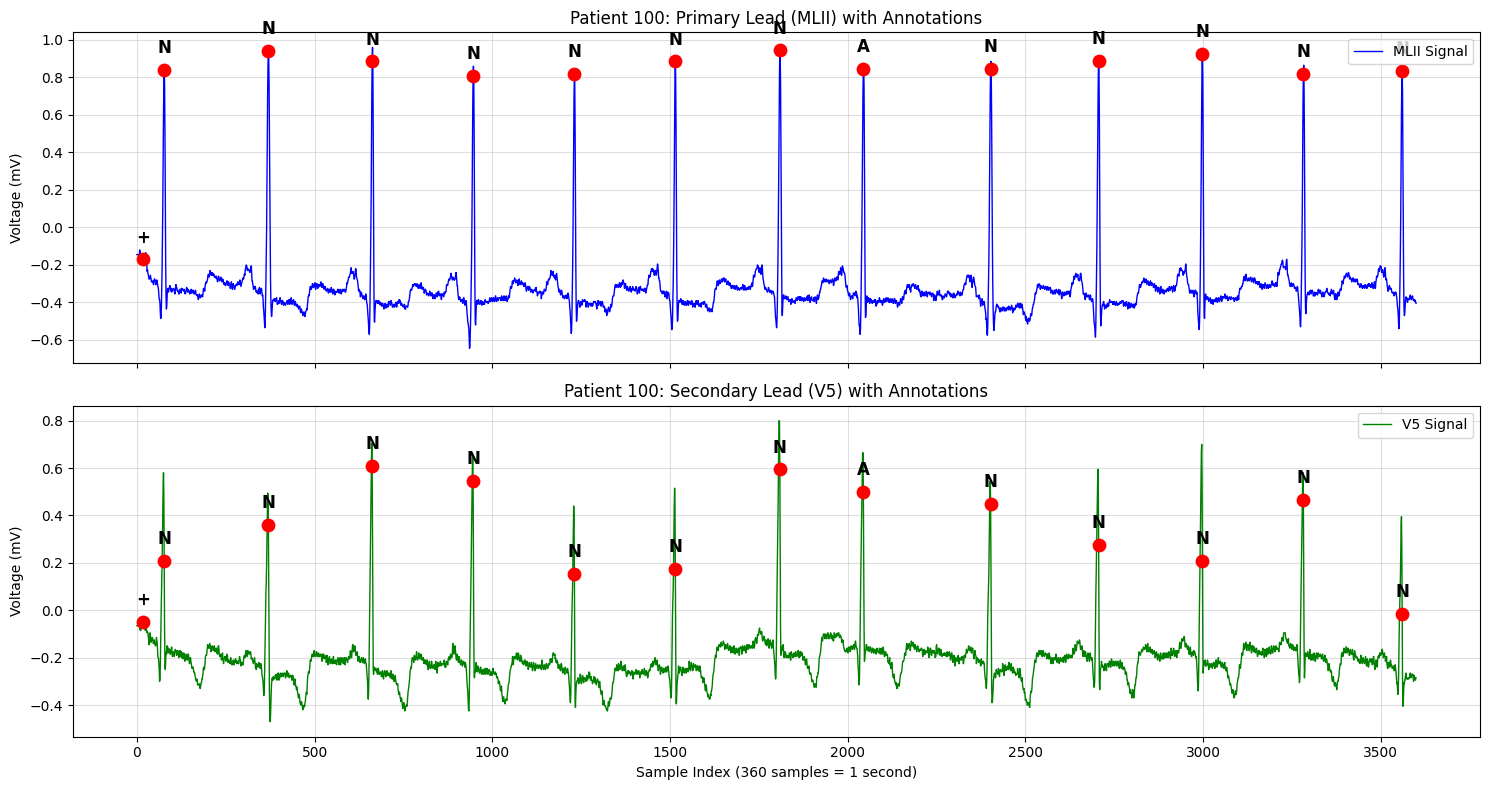

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the directory and load the specific files
data_dir = './mitbih_csv'
df_sig = pd.read_csv(f'{data_dir}/100_ekg.csv')
df_ann = pd.read_csv(f'{data_dir}/100_annotations_1.csv')

# 2. Define a viewing window
# 360 Hz means 360 rows per second. We will view the first 5 seconds.
fs = 360
seconds_to_view = 10
window_end = fs * seconds_to_view

# Slice the dataframes to our defined window
sig_window = df_sig.iloc[:window_end]
ann_window = df_ann[df_ann['index'] < window_end]

# 3. Construct a figure with two subplots (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# --- Top Subplot: MLII Lead ---
ax1.plot(sig_window.index, sig_window['MLII'], label='MLII Signal', color='blue', linewidth=1)

# Apply annotations to the MLII plot
for idx, symbol in zip(ann_window['index'], ann_window['annotation_symbol']):
    y_val = df_sig['MLII'].iloc[idx]
    ax1.scatter(idx, y_val, color='red', s=80, zorder=5)
    ax1.annotate(symbol, (idx, y_val), textcoords="offset points", xytext=(0, 12), ha='center', fontsize=12, fontweight='bold')

ax1.set_title('Patient 100: Primary Lead (MLII) with Annotations')
ax1.set_ylabel('Voltage (mV)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.4)

# --- Bottom Subplot: V5 Lead ---
ax2.plot(sig_window.index, sig_window['V5'], label='V5 Signal', color='green', linewidth=1)

# Apply annotations to the V5 plot to verify alignment across both leads
for idx, symbol in zip(ann_window['index'], ann_window['annotation_symbol']):
    y_val = df_sig['V5'].iloc[idx]
    ax2.scatter(idx, y_val, color='red', s=80, zorder=5)
    ax2.annotate(symbol, (idx, y_val), textcoords="offset points", xytext=(0, 12), ha='center', fontsize=12, fontweight='bold')

ax2.set_title('Patient 100: Secondary Lead (V5) with Annotations')
ax2.set_xlabel('Sample Index (360 samples = 1 second)')
ax2.set_ylabel('Voltage (mV)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.4)

# Format and display
plt.tight_layout()
plt.show()

In [6]:
from scipy.signal import butter, filtfilt

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SIGNAL_COL     = 'MLII'
ANN_SAMPLE_COL = 'index'
ANN_SYMBOL_COL = 'annotation_symbol'
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WINDOW = 180   # 180 samples each side → 360 total per beat
FS     = 360   # MIT-BIH sampling rate (Hz)

LABEL_MAP = {
    'N': 0, '.': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,   # Normal
    'A': 1, 'a': 1, 'J': 1, 'S': 1,                    # SVEB
    'V': 2, 'E': 2,                                      # VEB
    'F': 3,                                              # Fusion
    '/': 4, 'f': 4, 'Q': 4                              # Unknown/Paced
}

# ── Step 1: Index all files by record ID ─────────
all_files = os.listdir(data_dir)

record_ids = sorted(set(
    f.split('_')[0] for f in all_files
    if f.endswith('_ekg.csv')
))

# Map each record_id → list of annotation files (handles _1, _2, _3)
ann_map = defaultdict(list)
for f in all_files:
    if 'annotations' in f and f.endswith('.csv'):
        rid = f.split('_annotations')[0]
        ann_map[rid].append(f)

print(f"Records found: {len(record_ids)}")
print(f"Sample ann_map entry: {record_ids[0]} → {ann_map[record_ids[0]]}")

# ── Step 2: Helper functions ────────────────────
def bandpass_filter(sig, lo=0.5, hi=50, fs=FS, order=4):
    nyq = fs / 2
    b, a = butter(order, [lo/nyq, hi/nyq], btype='band')
    return filtfilt(b, a, sig)

def load_annotations(record_id):
    """Load & merge all annotation files for a record (handles multiple annotators)."""
    frames = []
    for ann_file in sorted(ann_map[record_id]):  # sorted: _1 before _2
        df = pd.read_csv(os.path.join(data_dir, ann_file))
        frames.append(df[[ANN_SAMPLE_COL, ANN_SYMBOL_COL]])
    merged = pd.concat(frames).drop_duplicates(subset=ANN_SAMPLE_COL).sort_values(ANN_SAMPLE_COL)
    return merged.reset_index(drop=True)

def extract_beats(record_id):
    # Load & filter signal
    sig_df  = pd.read_csv(os.path.join(data_dir, f'{record_id}_ekg.csv'))

    # Dynamically select signal column
    current_signal_col = None
    if 'MLII' in sig_df.columns:
        current_signal_col = 'MLII'
    elif 'V5' in sig_df.columns:
        current_signal_col = 'V5'
    else:
        print(f"  ☢ Skipping record {record_id} as neither 'MLII' nor 'V5' signal columns were found.")
        return np.array([]), np.array([]) # Return empty arrays if no signal column is found

    signal  = sig_df[current_signal_col].values.astype(float)
    signal  = bandpass_filter(signal)
    signal  = (signal - signal.mean()) / signal.std()   # z-score

    # Load annotations
    ann_df  = load_annotations(record_id)

    beats, labels = [], []
    for _, row in ann_df.iterrows():
        idx   = int(row[ANN_SAMPLE_COL])
        sym   = str(row[ANN_SYMBOL_COL]).strip()
        label = LABEL_MAP.get(sym, -1)

        if label == -1:
            continue  # skip non-beat markers (+, ~, |, etc.)
        if WINDOW < idx < len(signal) - WINDOW:
            beats.append(signal[idx - WINDOW : idx + WINDOW])
            labels.append(label)

    return np.array(beats, dtype=np.float32), np.array(labels, dtype=np.int64)

# ── Step 3: Build full dataset ────────────────────
all_beats, all_labels, all_groups = [], [], []

for i, rid in enumerate(record_ids):
    beats, labels = extract_beats(rid)
    if len(beats) == 0:
        print(f"  ☢ Skipped {rid} (no valid beats)")
        continue
    all_beats.append(beats)
    all_labels.append(labels)
    all_groups.append(np.full(len(labels), i))   # patient ID for split
    print(f"  ✓ Record {rid:>5}: {len(labels):>5} beats | classes {np.unique(labels)}")

X      = np.concatenate(all_beats,  axis=0)
y      = np.concatenate(all_labels, axis=0)
groups = np.concatenate(all_groups, axis=0)

print(f"\n{'---'*15}") # Changed from ─ to -
print(f"  Total beats : {X.shape[0]:,}")
print(f"  Beat length : {X.shape[1]} samples")
unique, counts = np.unique(y, return_counts=True)
class_names = ['Normal','SVEB','VEB','Fusion','Unknown']
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({class_names[cls]:>8}): {cnt:>7,}  ({cnt/len(y)*100:.1f}%)")

Records found: 48
Sample ann_map entry: 100 → ['100_annotations_1.csv']
  ✓ Record   100:  2271 beats | classes [0 1 2]
  ✓ Record   101:  1864 beats | classes [0 1 4]
  ✓ Record   102:  2185 beats | classes [0 2 4]
  ✓ Record   103:  2083 beats | classes [0 1]
  ✓ Record   104:  2227 beats | classes [0 2 4]
  ✓ Record   105:  2572 beats | classes [0 2 4]
  ✓ Record   106:  2027 beats | classes [0 2]
  ✓ Record   107:  2136 beats | classes [2 4]
  ✓ Record   108:  1762 beats | classes [0 1 2 3]
  ✓ Record   109:  2530 beats | classes [0 2 3]
  ✓ Record   111:  2124 beats | classes [0 2]
  ✓ Record   112:  2537 beats | classes [0 1]
  ✓ Record   113:  1793 beats | classes [0 1]
  ✓ Record   114:  1879 beats | classes [0 1 2 3]
  ✓ Record   115:  1951 beats | classes [0]
  ✓ Record   116:  2411 beats | classes [0 1 2]
  ✓ Record   117:  2923 beats | classes [0 1]
  ✓ Record   118:  2277 beats | classes [0 1 2]
  ✓ Record   119:  2022 beats | classes [0 2]
  ✓ Record   121:  1861 beats | 

In [7]:
# Reshape X for sequence models (Samples, Timesteps, Features)
X = np.expand_dims(X, axis=-1)

print(f"  Final Feature Shape : {X.shape}")
# Expected output: (Total_Beats, 360, 1)

  Final Feature Shape : (110861, 360, 1)


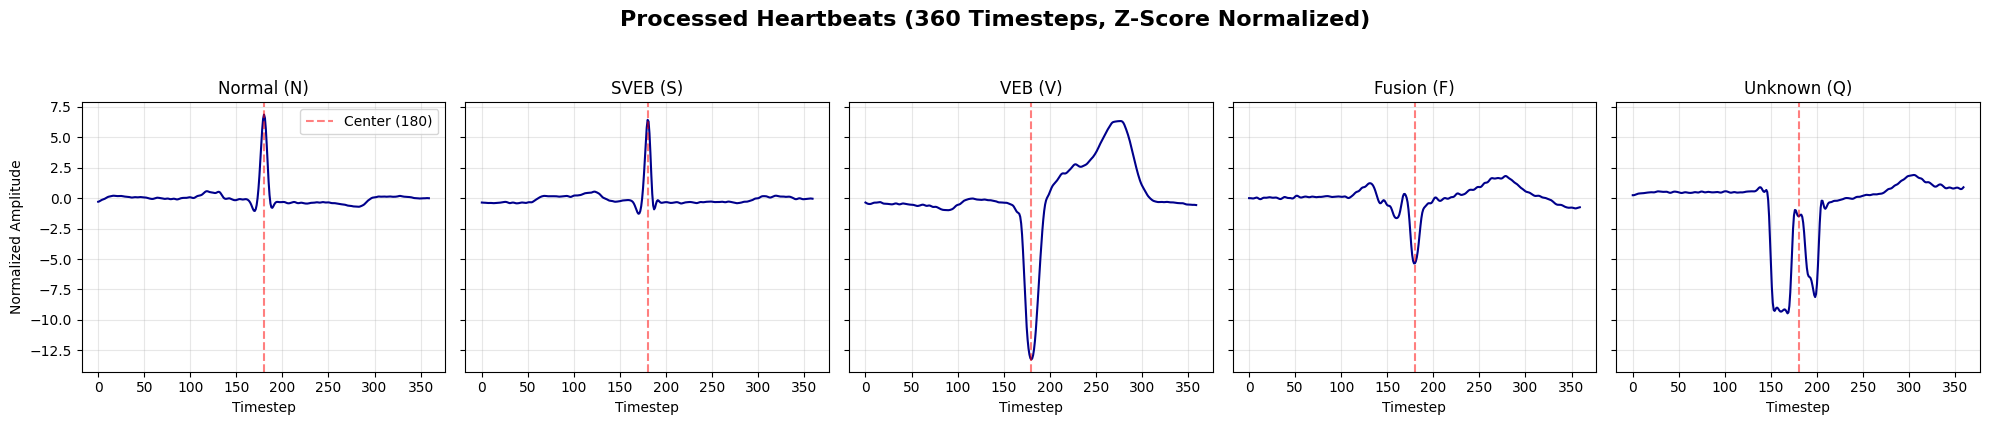

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Define the AAMI categories
class_names = ['Normal (N)', 'SVEB (S)', 'VEB (V)', 'Fusion (F)', 'Unknown (Q)']

# Create a figure with 5 subplots arranged horizontally
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('Processed Heartbeats (360 Timesteps, Z-Score Normalized)', fontsize=16, fontweight='bold', y=1.05)

# Loop through each of the 5 classes
for i in range(5):
    # Find all indices in your dataset that belong to the current class
    class_indices = np.where(y == i)[0]

    if len(class_indices) > 0:
        sample_idx = class_indices[0]

        # Extract the 360 timesteps.
        # X has shape (Samples, 360, 1), so we select the specific sample and the 0th feature
        beat_signal = X[sample_idx, :, 0]

        # Plot the heartbeat
        axes[i].plot(beat_signal, color='darkblue')
        axes[i].set_title(class_names[i])
        axes[i].set_xlabel('Timestep')
        axes[i].grid(True, alpha=0.3)

        # Highlight the center (where the R-peak should roughly align due to your windowing)
        axes[i].axvline(x=180, color='red', linestyle='--', alpha=0.5, label='Center (180)')
        if i == 0:
            axes[i].legend()

# Set the Y-axis label only on the first plot to avoid clutter
axes[0].set_ylabel('Normalized Amplitude')

plt.tight_layout()
plt.show()

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Reshape for PyTorch (Move the '1' feature to the middle)
# From (110861, 360, 1) -> (110861, 1, 360)
X_torch = np.transpose(X, (0, 2, 1))

# 2. Split into Training and Testing sets (using 80% for training)
X_train, X_test, y_train, y_test = train_test_split(X_torch, y, test_size=0.2, random_state=42)

# 3. Convert NumPy arrays to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 4. Create DataLoaders (Feeds the model 64 heartbeats at a time)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"PyTorch Training Tensor Shape: {X_train_tensor.shape}")

PyTorch Training Tensor Shape: torch.Size([88688, 1, 360])


#**Custom 1D CNN**

In [10]:
class TemporalAttention(nn.Module):
    def __init__(self, feature_dim):
        super(TemporalAttention, self).__init__()
        # The attention mechanism is a small neural network itself
        self.attention_network = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // 2),
            nn.Tanh(),
            nn.Linear(feature_dim // 2, 1) # Outputs a single score per timestep
        )

    def forward(self, x):
        # x shape: (Batch, Timesteps, Features)

        # 1. Calculate raw importance scores for every timestep
        attn_scores = self.attention_network(x)

        # 2. Convert scores to percentages (0.0 to 1.0) using Softmax
        # This ensures all weights across the 360 timesteps add up to 100%
        attn_weights = torch.softmax(attn_scores, dim=1)

        # 3. Multiply the original features by their attention percentage
        # Important moments stay strong; useless noise gets multiplied by ~0
        weighted_features = x * attn_weights

        # 4. Compress the sequence down into a single summary vector
        context_vector = torch.sum(weighted_features, dim=1)

        return context_vector, attn_weights

class ECGClassifier(nn.Module):
    def __init__(self):
        super(ECGClassifier, self).__init__()

        # --- Feature Extraction ---
        # Scans the wave looking for sharp drops or wide curves
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # Shrinks sequence from 360 to 180

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # Shrinks sequence from 180 to 90
        )

        # --- Temporal Attention ---
        # 64 is the number of out_channels from the last CNN layer
        self.attention = TemporalAttention(feature_dim=64)

        # --- Classification Head ---
        # Maps the final summary vector to our 5 AAMI categories
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3), # Prevents memorization
            nn.Linear(32, 5) # 5 final output nodes (0, 1, 2, 3, 4)
        )

    def forward(self, x):
        # 1. Pass raw signal through CNN
        # Input shape: (Batch, 1, 360) -> Output shape: (Batch, 64, 90)
        features = self.cnn(x)

        # 2. Prepare for Attention
        # Attention needs (Batch, Timesteps, Features), so we swap the last two axes
        features = features.permute(0, 2, 1) # Shape: (Batch, 90, 64)

        # 3. Apply Temporal Attention
        context_vector, attention_weights = self.attention(features)

        # 4. Final Classification
        predictions = self.classifier(context_vector)

        return predictions

# Initialize the model and move it to the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ECGClassifier().to(device)

print(model)

ECGClassifier(
  (cnn): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (attention): TemporalAttention(
    (attention_network): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): Tanh()
      (2): Linear(in_features=32, out_features=1, bias=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=5, bias=True)
  )
)


#**RNN**

In [11]:
import torch
import torch.nn as nn

class ECGLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=5):
        super(ECGLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # The LSTM layer
        # batch_first=True means the input tensor is (Batch, Timesteps, Features)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 # Regularization between LSTM layers
        )

        # Classification head
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # 1. Reshape Input: PyTorch Conv1d wanted (Batch, Channels, Timesteps)
        # LSTM wants (Batch, Timesteps, Channels).
        # So we permute (Batch, 1, 360) -> (Batch, 360, 1)
        x = x.permute(0, 2, 1)

        # 2. Pass through LSTM
        # lstm_out contains all hidden states across all timesteps
        lstm_out, _ = self.lstm(x)

        # 3. Extract the final timestep
        # We only care about the network's understanding at the very end of the heartbeat
        final_state = lstm_out[:, -1, :]

        # 4. Classify
        out = self.fc(final_state)
        return out

In [12]:
model_lstm = ECGLSTM().to(device)
print(model_lstm)

ECGLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)


#**ResNet**

In [13]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock1D, self).__init__()

        # Main pathway
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=5, stride=stride, padding=2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(out_channels)

        # Skip connection pathway
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # The core ResNet concept: Add the skipped signal back into the processed signal
        out += residual
        out = self.relu(out)
        return out

class ECGResNet(nn.Module):
    def __init__(self, num_classes=5):
        super(ECGResNet, self).__init__()

        self.initial_layer = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3), # Shrinks 360 -> 180
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)      # Shrinks 180 -> 90
        )

        # Two Residual Blocks
        self.layer1 = ResidualBlock1D(32, 64, stride=2)           # Shrinks 90 -> 45
        self.layer2 = ResidualBlock1D(64, 128, stride=2)          # Shrinks 45 -> 23

        # Global Average Pooling flattens whatever sequence length is left
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.initial_layer(x)
        x = self.layer1(x)
        x = self.layer2(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1) # Flatten for the linear layer
        out = self.fc(x)
        return out

model_resnet = ECGResNet().to(device)
print(model_resnet)

ECGResNet(
  (initial_layer): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): ResidualBlock1D(
    (conv1): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv1d(32, 64, kernel_size=(1,), stride=(2,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): ResidualBlock1D(
    (conv1): Conv1d(64, 128, kernel_size=(5,), stride=(2,), padding=(2,))
    (bn1): BatchNorm1d(128, eps=

# **Transformer**

In [14]:
class ECGTransformer(nn.Module):
    def __init__(self, sequence_length=360, num_classes=5, d_model=64, nhead=4, num_layers=2):
        super(ECGTransformer, self).__init__()

        # 1. Projection: Converts the 1-value timestep into a 64-value vector
        self.embedding = nn.Linear(1, d_model)

        # 2. Positional Encoding: A learnable parameter that tells the transformer
        # the chronological order of the 360 points.
        self.pos_encoder = nn.Parameter(torch.randn(1, sequence_length, d_model))

        # 3. The Transformer Encoder
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model*2,
            dropout=0.1,
            batch_first=True # Expects (Batch, Timesteps, d_model)
        )
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        # 4. Classification Head
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        # Permute (Batch, 1, 360) -> (Batch, 360, 1)
        x = x.permute(0, 2, 1)

        # Project 1 feature to 64 features
        x = self.embedding(x)

        # Add position information
        x = x + self.pos_encoder

        # Pass through the self-attention transformer
        x = self.transformer(x)

        # Global Average Pooling: Compress the 360 timesteps into one summary vector
        x = x.mean(dim=1)

        # Final classification
        out = self.fc(x)
        return out

model_transformer = ECGTransformer().to(device)
print(model_transformer)

ECGTransformer(
  (embedding): Linear(in_features=1, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=5, bias=True)
  )
)


In [ ]:
import torch.optim as optim
import time
import torch.nn as nn
import torch

# 1. Initialize all architectures and move them to the GPU
models_to_test = {
    "CNN_Temporal_Attention": ECGClassifier().to(device),
    "LSTM": ECGLSTM().to(device),
    "ResNet1D": ECGResNet().to(device),
    "Transformer": ECGTransformer().to(device)
}

# Dictionary to store the highest accuracy achieved by each model
results_summary = {}

num_epochs = 10
criterion = nn.CrossEntropyLoss()

print("Starting Comparative Training Phase...")
print("=" * 60)

# 2. Iterate through each model
for model_name, current_model in models_to_test.items():
    print(f"\nTraining Architecture: {model_name}")
    print("-" * 40)

    # Initialize a new optimizer specific to the current model's parameters
    optimizer = optim.Adam(current_model.parameters(), lr=0.001)

    start_time = time.time()
    best_test_acc = 0.0

    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        current_model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = current_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = 100 * correct_train / total_train

        # --- VALIDATION PHASE ---
        current_model.eval()
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = current_model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_acc = 100 * correct_test / total_test

        # Track the highest validation accuracy for this architecture
        if test_acc > best_test_acc:
            best_test_acc = test_acc

        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    # Calculate execution time
    end_time = time.time()
    training_time = (end_time - start_time) / 60

    print(f"Completion: {model_name} finished in {training_time:.1f} minutes. Peak Test Accuracy: {best_test_acc:.2f}%\n")

    # Store the result for the final comparison matrix
    results_summary[model_name] = best_test_acc

# 3. Final Evaluation Ranking
print("=" * 60)
print("FINAL ARCHITECTURE RANKING")
print("=" * 60)

# Sort the dictionary by accuracy in descending order
sorted_results = sorted(results_summary.items(), key=lambda item: item[1], reverse=True)

for rank, (model, acc) in enumerate(sorted_results, 1):
    print(f"Rank {rank}: {model:>25} | Peak Accuracy: {acc:.2f}%")

Starting Comparative Training Phase...

Training Architecture: CNN_Temporal_Attention
----------------------------------------
Epoch [1/10] | Loss: 0.4029 | Train Acc: 88.34% | Test Acc: 92.61%
Epoch [2/10] | Loss: 0.2598 | Train Acc: 92.51% | Test Acc: 94.20%
Epoch [3/10] | Loss: 0.2263 | Train Acc: 93.55% | Test Acc: 94.76%
Epoch [4/10] | Loss: 0.2056 | Train Acc: 94.09% | Test Acc: 94.54%
Epoch [5/10] | Loss: 0.1902 | Train Acc: 94.57% | Test Acc: 95.16%
Epoch [6/10] | Loss: 0.1795 | Train Acc: 94.84% | Test Acc: 95.68%
Epoch [7/10] | Loss: 0.1710 | Train Acc: 95.16% | Test Acc: 95.44%
Epoch [8/10] | Loss: 0.1609 | Train Acc: 95.38% | Test Acc: 96.03%
Epoch [9/10] | Loss: 0.1547 | Train Acc: 95.58% | Test Acc: 95.99%
Epoch [10/10] | Loss: 0.1473 | Train Acc: 95.84% | Test Acc: 96.04%
Completion: CNN_Temporal_Attention finished in 1.2 minutes. Peak Test Accuracy: 96.04%


Training Architecture: LSTM
----------------------------------------
Epoch [1/10] | Loss: 0.6345 | Train Acc: 83.

#**Visualization**

Generating detailed evaluation metrics...


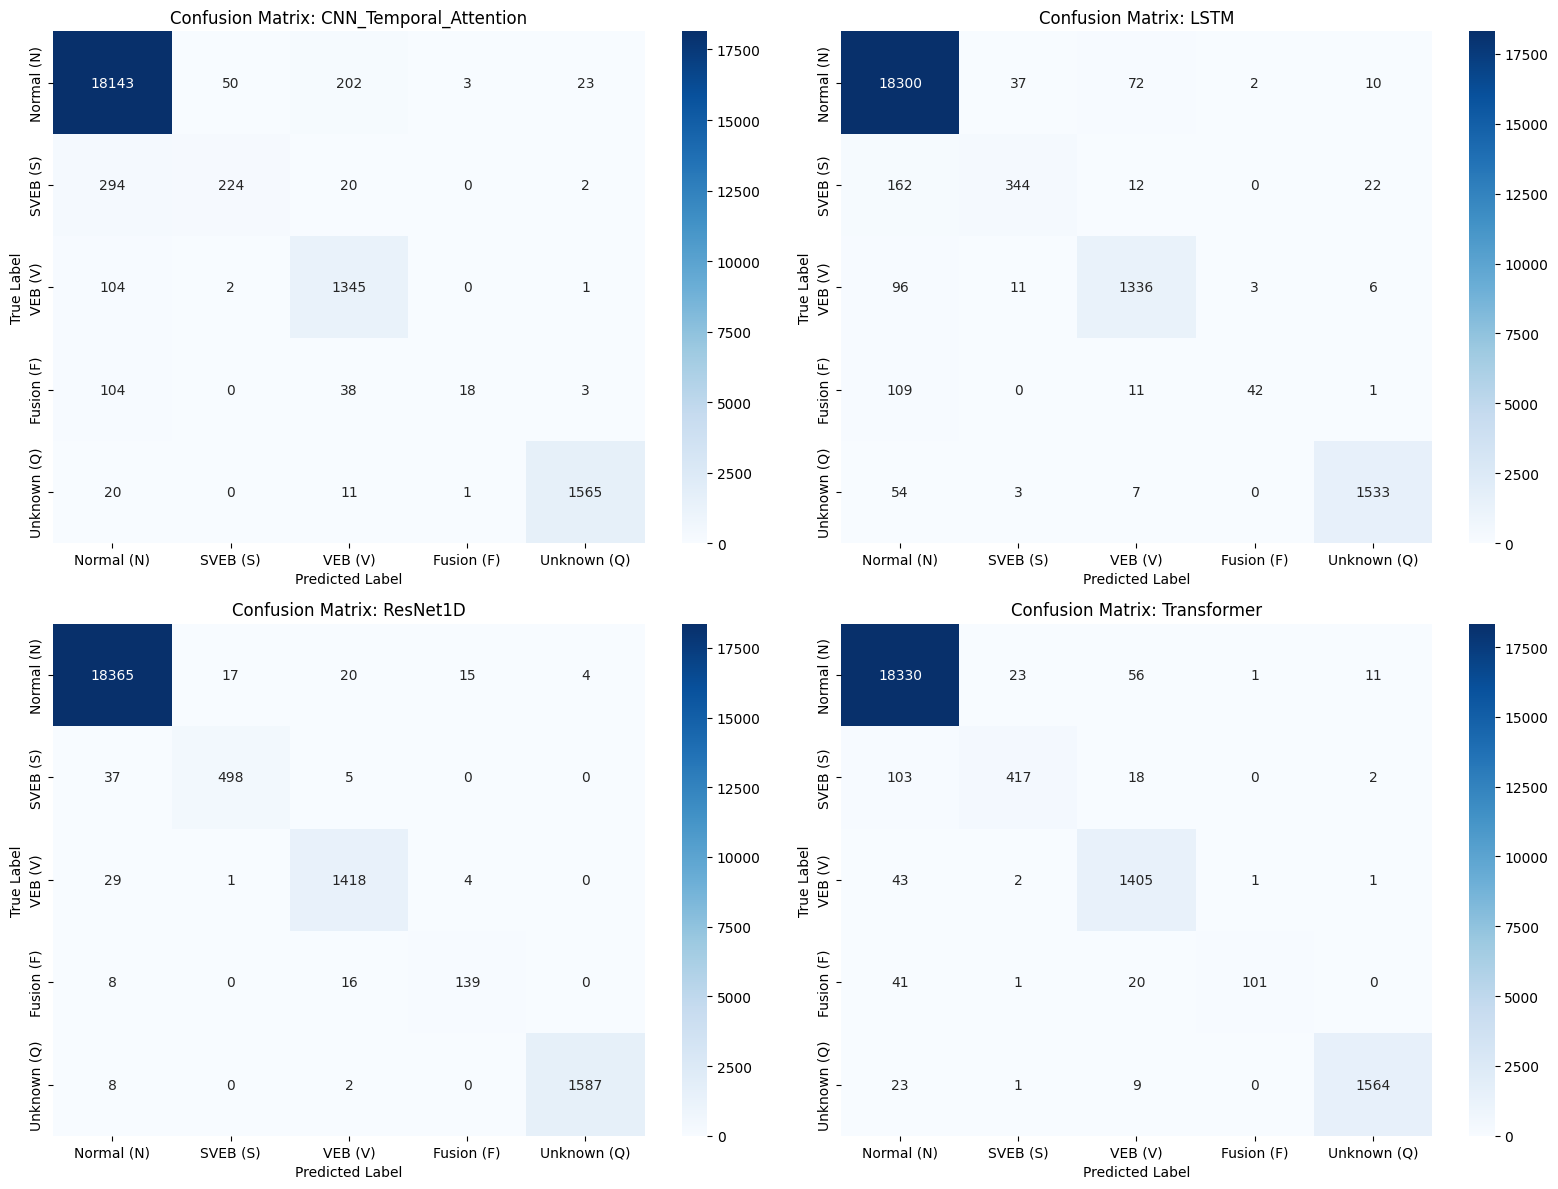

/tmp/ipykernel_5793/1521133103.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Macro F1', y='Model', data=perf_df, palette='viridis')


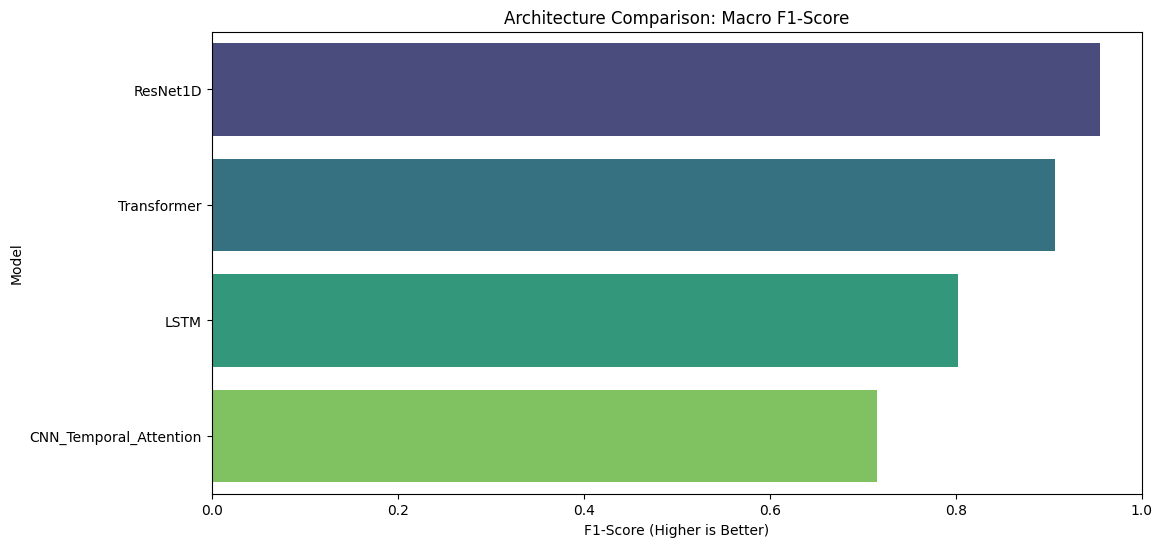

/tmp/ipykernel_5793/1521133103.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Macro AUPRC', y='Model', data=perf_df.sort_values(by='Macro AUPRC', ascending=False), palette='magma')


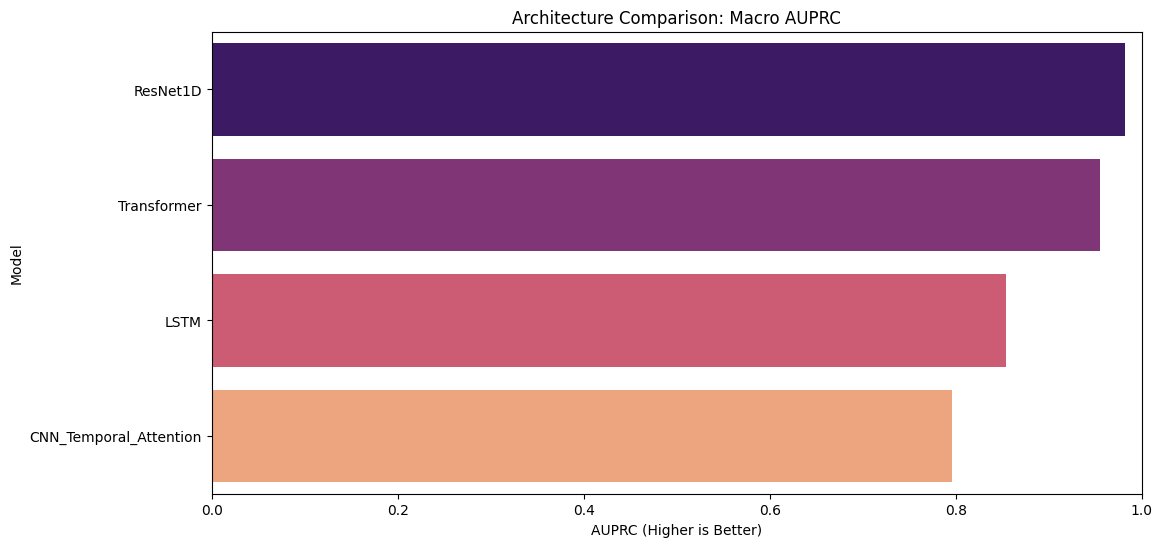


Detailed Performance Breakdown:
                    Model  Accuracy  Precision    Recall  Macro F1  \
2                ResNet1D  0.992513   0.992465  0.992513  0.954932   
3             Transformer  0.983944   0.983854  0.983944  0.906667   
1                    LSTM  0.972128   0.970959  0.972128  0.802660   
0  CNN_Temporal_Attention  0.960402   0.958549  0.960402  0.715944   

   Macro AUPRC  
2     0.982236  
3     0.955036  
1     0.854532  
0     0.796331  

Plotting ROC and Precision-Recall Curves for ResNet1D (Best Performing Model)...


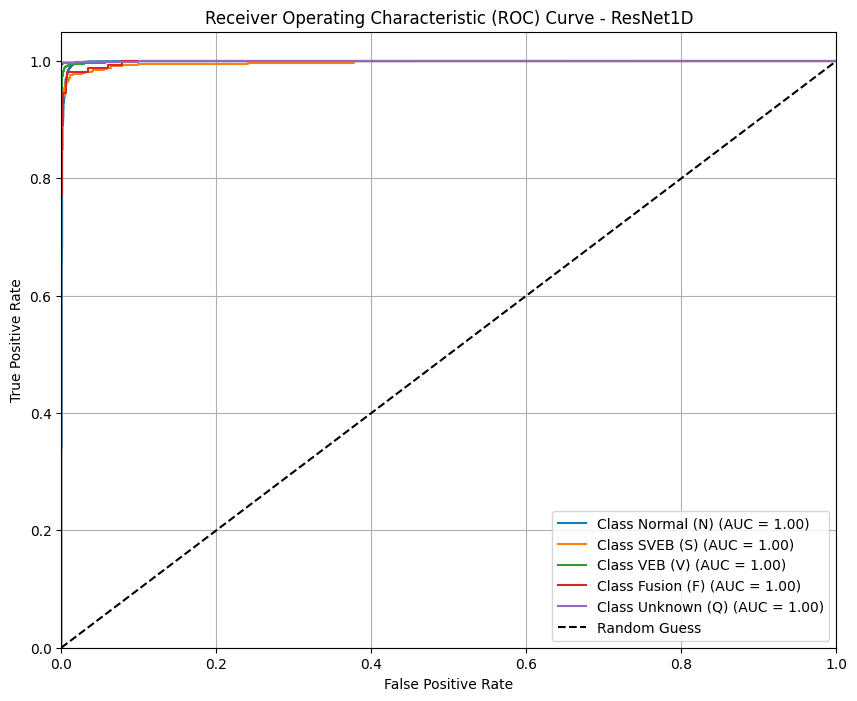

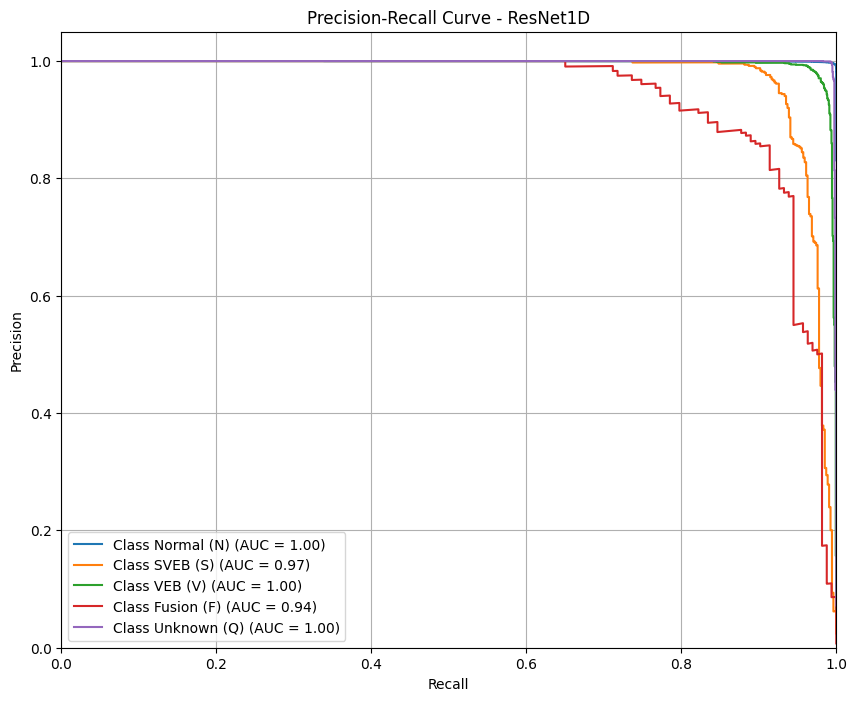

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported
import torch # Added for softmax

# 1. Setup the visualization space for Confusion Matrices
fig_cm, axes_cm = plt.subplots(2, 2, figsize=(16, 12))
axes_cm = axes_cm.flatten()
comparison_metrics = []

print("Generating detailed evaluation metrics...")

# Store predictions and probabilities for all models for later plotting
all_models_data = {}

# 2. Iterate through models to collect predictions and probabilities
for i, (model_name, model) in enumerate(models_to_test.items()):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = [] # To store probabilities for ROC/PR curves

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1) # Get probabilities

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy()) # Store probabilities

    all_models_data[model_name] = {
        'preds': all_preds,
        'labels': all_labels,
        'probs': np.array(all_probs)
    }

    # 3. Calculate metrics
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']

    # Calculate Macro AUPRC for the current model
    y_true_current_model = np.array(all_labels)
    y_score_current_model = np.array(all_probs)
    y_true_binarized_current_model = label_binarize(y_true_current_model, classes=np.unique(y_true_current_model))
    n_classes_current_model = y_true_binarized_current_model.shape[1]

    pr_auc_per_class = []
    for cls_idx in range(n_classes_current_model):
        precision_cls, recall_cls, _ = precision_recall_curve(y_true_binarized_current_model[:, cls_idx], y_score_current_model[:, cls_idx])
        # Handle cases where a class might not have any positive samples or predictions
        if not np.isnan(auc(recall_cls, precision_cls)):
            pr_auc_per_class.append(auc(recall_cls, precision_cls))
        else:
            pr_auc_per_class.append(0.0) # Assign 0 or handle as appropriate

    macro_auprc = np.mean(pr_auc_per_class) # Macro average AUPRC

    comparison_metrics.append({
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Precision': precision,
        'Recall': recall,
        'Macro F1': f1,
        'Macro AUPRC': macro_auprc
    })

    # 4. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[i],
                xticklabels=class_names, yticklabels=class_names)
    axes_cm[i].set_title(f'Confusion Matrix: {model_name}')
    axes_cm[i].set_ylabel('True Label')
    axes_cm[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show(fig_cm) # Show confusion matrices first

# 5. Final Comparative Visualization (Macro F1 and Macro AUPRC)
perf_df = pd.DataFrame(comparison_metrics).sort_values(by='Macro F1', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Macro F1', y='Model', data=perf_df, palette='viridis')
plt.title('Architecture Comparison: Macro F1-Score')
plt.xlabel('F1-Score (Higher is Better)')
plt.xlim(0, 1.0)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Macro AUPRC', y='Model', data=perf_df.sort_values(by='Macro AUPRC', ascending=False), palette='magma')
plt.title('Architecture Comparison: Macro AUPRC')
plt.xlabel('AUPRC (Higher is Better)')
plt.xlim(0, 1.0)
plt.show()

print("\nDetailed Performance Breakdown:")
print(perf_df)

# --- Plot ROC and Precision-Recall Curves for the best performing model (ResNet1D) ---
print("\nPlotting ROC and Precision-Recall Curves for ResNet1D (Best Performing Model)...")

best_model_name = perf_df.iloc[0]['Model']
best_model_data = all_models_data[best_model_name]
y_true = np.array(best_model_data['labels'])
y_score = best_model_data['probs']

# Binarize the true labels for multi-class ROC and PR curves
y_true_binarized = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binarized.shape[1]

# Setup for ROC Curve
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    ax_roc.plot(fpr[i], tpr[i], label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

ax_roc.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title(f'Receiver Operating Characteristic (ROC) Curve - {best_model_name}')
ax_roc.legend(loc='lower right')
ax_roc.grid(True)
plt.show(fig_roc)

# Setup for Precision-Recall Curve
fig_pr, ax_pr = plt.subplots(figsize=(10, 8))
precision_pr = dict() # Renamed to avoid conflict with `precision` variable for weighted avg
recall_pr = dict()     # Renamed to avoid conflict with `recall` variable for weighted avg
pr_auc_single_class = dict() # Renamed to clearly indicate this is for single classes

for i in range(n_classes):
    precision_pr[i], recall_pr[i], _ = precision_recall_curve(y_true_binarized[:, i], y_score[:, i])
    pr_auc_single_class[i] = auc(recall_pr[i], precision_pr[i])
    ax_pr.plot(recall_pr[i], precision_pr[i], label=f'Class {class_names[i]} (AUC = {pr_auc_single_class[i]:.2f})')

ax_pr.set_xlim([0.0, 1.0])
ax_pr.set_ylim([0.0, 1.05])
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title(f'Precision-Recall Curve - {best_model_name}')
ax_pr.legend(loc='lower left')
ax_pr.grid(True)
plt.show(fig_pr)


#**balancing classes using class weighting**

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. Calculate weights: Weight = Total_Samples / (n_classes * samples_in_class)
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to a PyTorch tensor and move to GPU
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print("Calculated Class Weights:")
for i, weight in enumerate(weights):
    print(f"  {class_names[i]}: {weight:.2f}")

Calculated Class Weights:
  Normal (N): 0.24
  SVEB (S): 7.91
  VEB (V): 3.05
  Fusion (F): 27.76
  Unknown (Q): 2.75


In [19]:
import torch.optim as optim
import time
import torch.nn as nn
import torch

# 1. Initialize all architectures and move them to the GPU
models_to_test = {
    "CNN_Temporal_Attention": ECGClassifier().to(device),
    "LSTM": ECGLSTM().to(device),
    "ResNet1D": ECGResNet().to(device),
    "Transformer": ECGTransformer().to(device)
}

# Dictionary to store the highest accuracy achieved by each model
results_summary = {}

num_epochs = 10
criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Starting Comparative Training Phase...")
print("=" * 60)

# 2. Iterate through each model
for model_name, current_model in models_to_test.items():
    print(f"\nTraining Architecture: {model_name}")
    print("-" * 40)

    # Initialize a new optimizer specific to the current model's parameters
    optimizer = optim.Adam(current_model.parameters(), lr=0.001)

    start_time = time.time()
    best_test_acc = 0.0

    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        current_model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = current_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = 100 * correct_train / total_train

        # --- VALIDATION PHASE ---
        current_model.eval()
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = current_model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_acc = 100 * correct_test / total_test

        # Track the highest validation accuracy for this architecture
        if test_acc > best_test_acc:
            best_test_acc = test_acc

        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    # Calculate execution time
    end_time = time.time()
    training_time = (end_time - start_time) / 60

    print(f"Completion: {model_name} finished in {training_time:.1f} minutes. Peak Test Accuracy: {best_test_acc:.2f}%\n")

    # Store the result for the final comparison matrix
    results_summary[model_name] = best_test_acc

# 3. Final Evaluation Ranking
print("=" * 60)
print("FINAL ARCHITECTURE RANKING")
print("=" * 60)

# Sort the dictionary by accuracy in descending order
sorted_results = sorted(results_summary.items(), key=lambda item: item[1], reverse=True)

for rank, (model, acc) in enumerate(sorted_results, 1):
    print(f"Rank {rank}: {model:>25} | Peak Accuracy: {acc:.2f}%")

Starting Comparative Training Phase...

Training Architecture: CNN_Temporal_Attention
----------------------------------------
Epoch [1/10] | Loss: 1.0478 | Train Acc: 57.81% | Test Acc: 67.10%
Epoch [2/10] | Loss: 0.7878 | Train Acc: 70.35% | Test Acc: 72.69%
Epoch [3/10] | Loss: 0.6052 | Train Acc: 77.35% | Test Acc: 83.96%
Epoch [4/10] | Loss: 0.5476 | Train Acc: 80.27% | Test Acc: 83.63%
Epoch [5/10] | Loss: 0.5025 | Train Acc: 81.59% | Test Acc: 88.54%
Epoch [6/10] | Loss: 0.4804 | Train Acc: 82.91% | Test Acc: 89.01%
Epoch [7/10] | Loss: 0.4548 | Train Acc: 83.94% | Test Acc: 81.75%
Epoch [8/10] | Loss: 0.4372 | Train Acc: 84.93% | Test Acc: 85.32%
Epoch [9/10] | Loss: 0.4253 | Train Acc: 86.00% | Test Acc: 80.13%
Epoch [10/10] | Loss: 0.4056 | Train Acc: 86.02% | Test Acc: 85.69%
Completion: CNN_Temporal_Attention finished in 1.1 minutes. Peak Test Accuracy: 89.01%


Training Architecture: LSTM
----------------------------------------
Epoch [1/10] | Loss: 1.3673 | Train Acc: 22.

Generating detailed evaluation metrics...


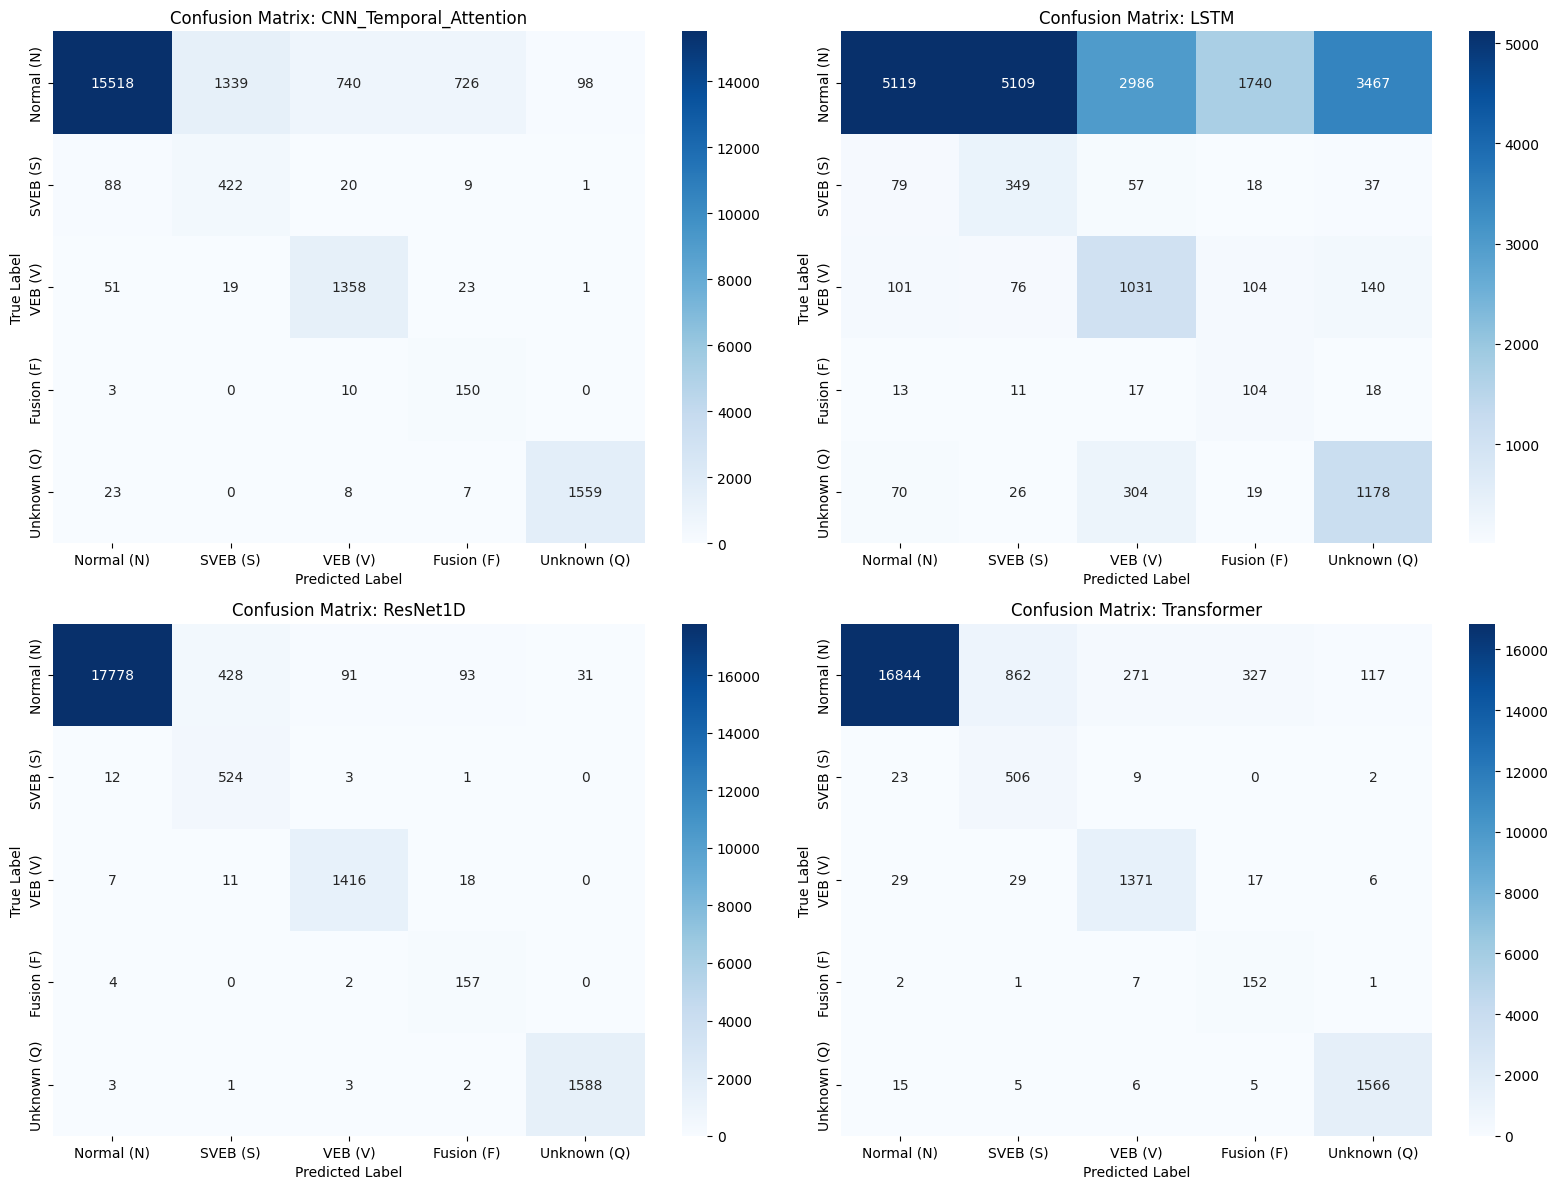

/tmp/ipykernel_2617/1521133103.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Macro F1', y='Model', data=perf_df, palette='viridis')


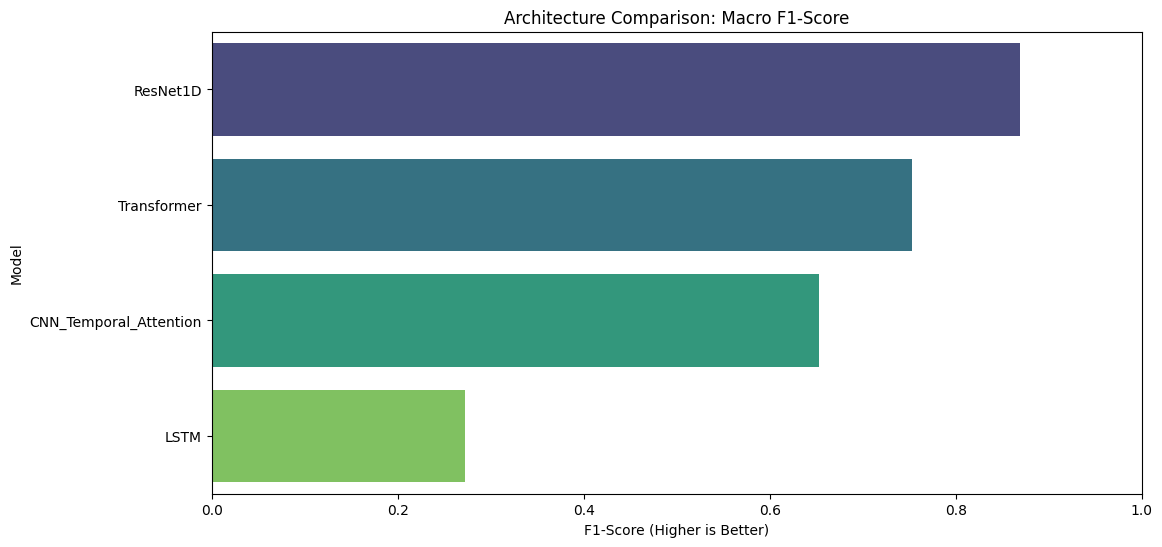

/tmp/ipykernel_2617/1521133103.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Macro AUPRC', y='Model', data=perf_df.sort_values(by='Macro AUPRC', ascending=False), palette='magma')


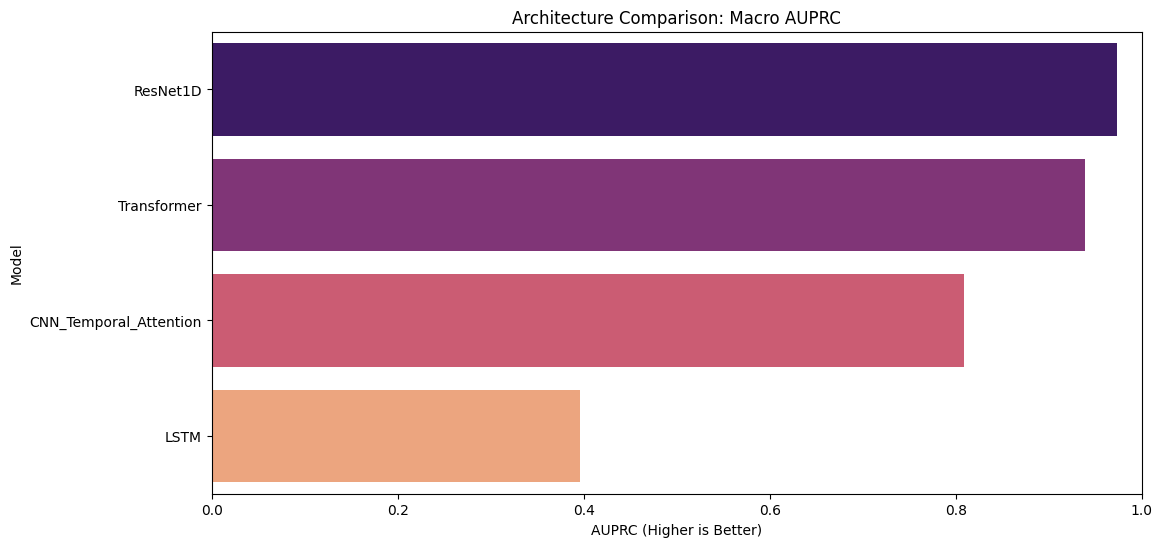


Detailed Performance Breakdown:
                    Model  Accuracy  Precision    Recall  Macro F1  \
2                ResNet1D  0.967979   0.978920  0.967979  0.868781   
3             Transformer  0.921797   0.959025  0.921797  0.752866   
0  CNN_Temporal_Attention  0.857214   0.938340  0.857214  0.653342   
1                    LSTM  0.350922   0.824990  0.350922  0.271967   

   Macro AUPRC  
2     0.973860  
3     0.938617  
0     0.809174  
1     0.396211  

Plotting ROC and Precision-Recall Curves for ResNet1D (Best Performing Model)...


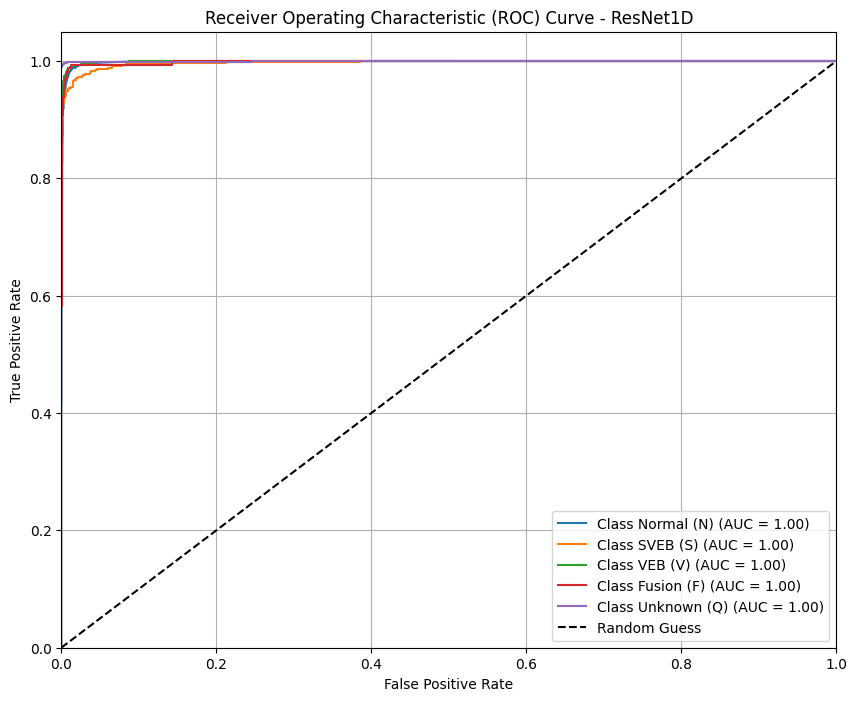

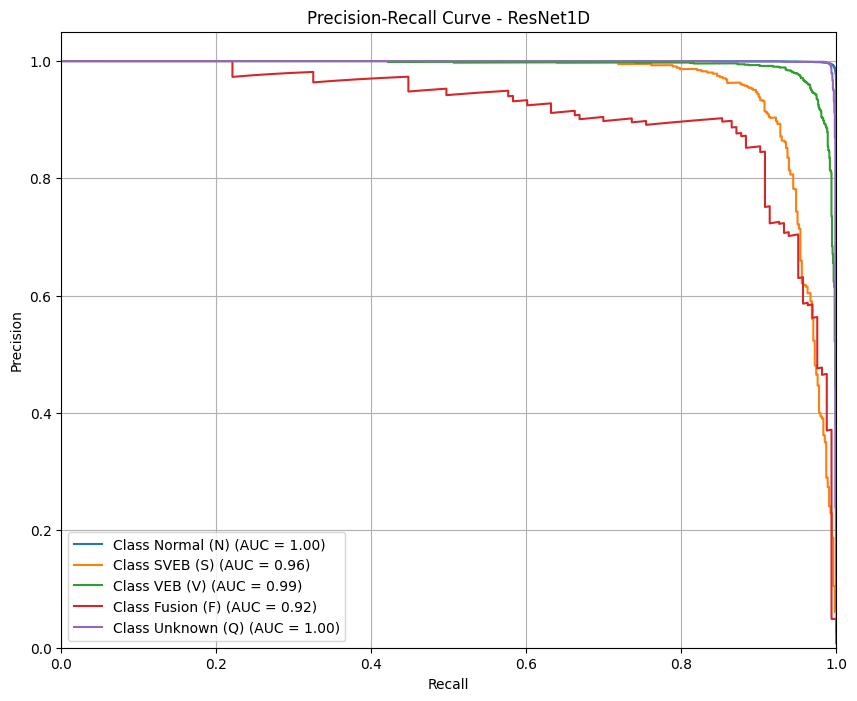

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported
import torch # Added for softmax

# 1. Setup the visualization space for Confusion Matrices
fig_cm, axes_cm = plt.subplots(2, 2, figsize=(16, 12))
axes_cm = axes_cm.flatten()
comparison_metrics = []

print("Generating detailed evaluation metrics...")

# Store predictions and probabilities for all models for later plotting
all_models_data = {}

# 2. Iterate through models to collect predictions and probabilities
for i, (model_name, model) in enumerate(models_to_test.items()):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = [] # To store probabilities for ROC/PR curves

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1) # Get probabilities

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy()) # Store probabilities

    all_models_data[model_name] = {
        'preds': all_preds,
        'labels': all_labels,
        'probs': np.array(all_probs)
    }

    # 3. Calculate metrics
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']

    # Calculate Macro AUPRC for the current model
    y_true_current_model = np.array(all_labels)
    y_score_current_model = np.array(all_probs)
    y_true_binarized_current_model = label_binarize(y_true_current_model, classes=np.unique(y_true_current_model))
    n_classes_current_model = y_true_binarized_current_model.shape[1]

    pr_auc_per_class = []
    for cls_idx in range(n_classes_current_model):
        precision_cls, recall_cls, _ = precision_recall_curve(y_true_binarized_current_model[:, cls_idx], y_score_current_model[:, cls_idx])
        # Handle cases where a class might not have any positive samples or predictions
        if not np.isnan(auc(recall_cls, precision_cls)):
            pr_auc_per_class.append(auc(recall_cls, precision_cls))
        else:
            pr_auc_per_class.append(0.0) # Assign 0 or handle as appropriate

    macro_auprc = np.mean(pr_auc_per_class) # Macro average AUPRC

    comparison_metrics.append({
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Precision': precision,
        'Recall': recall,
        'Macro F1': f1,
        'Macro AUPRC': macro_auprc
    })

    # 4. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[i],
                xticklabels=class_names, yticklabels=class_names)
    axes_cm[i].set_title(f'Confusion Matrix: {model_name}')
    axes_cm[i].set_ylabel('True Label')
    axes_cm[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show(fig_cm) # Show confusion matrices first

# 5. Final Comparative Visualization (Macro F1 and Macro AUPRC)
perf_df = pd.DataFrame(comparison_metrics).sort_values(by='Macro F1', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Macro F1', y='Model', data=perf_df, palette='viridis')
plt.title('Architecture Comparison: Macro F1-Score')
plt.xlabel('F1-Score (Higher is Better)')
plt.xlim(0, 1.0)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Macro AUPRC', y='Model', data=perf_df.sort_values(by='Macro AUPRC', ascending=False), palette='magma')
plt.title('Architecture Comparison: Macro AUPRC')
plt.xlabel('AUPRC (Higher is Better)')
plt.xlim(0, 1.0)
plt.show()

print("\nDetailed Performance Breakdown:")
print(perf_df)

# --- Plot ROC and Precision-Recall Curves for the best performing model (ResNet1D) ---
print("\nPlotting ROC and Precision-Recall Curves for ResNet1D (Best Performing Model)...")

best_model_name = perf_df.iloc[0]['Model']
best_model_data = all_models_data[best_model_name]
y_true = np.array(best_model_data['labels'])
y_score = best_model_data['probs']

# Binarize the true labels for multi-class ROC and PR curves
y_true_binarized = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binarized.shape[1]

# Setup for ROC Curve
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    ax_roc.plot(fpr[i], tpr[i], label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

ax_roc.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title(f'Receiver Operating Characteristic (ROC) Curve - {best_model_name}')
ax_roc.legend(loc='lower right')
ax_roc.grid(True)
plt.show(fig_roc)

# Setup for Precision-Recall Curve
fig_pr, ax_pr = plt.subplots(figsize=(10, 8))
precision_pr = dict() # Renamed to avoid conflict with `precision` variable for weighted avg
recall_pr = dict()     # Renamed to avoid conflict with `recall` variable for weighted avg
pr_auc_single_class = dict() # Renamed to clearly indicate this is for single classes

for i in range(n_classes):
    precision_pr[i], recall_pr[i], _ = precision_recall_curve(y_true_binarized[:, i], y_score[:, i])
    pr_auc_single_class[i] = auc(recall_pr[i], precision_pr[i])
    ax_pr.plot(recall_pr[i], precision_pr[i], label=f'Class {class_names[i]} (AUC = {pr_auc_single_class[i]:.2f})')

ax_pr.set_xlim([0.0, 1.0])
ax_pr.set_ylim([0.0, 1.05])
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title(f'Precision-Recall Curve - {best_model_name}')
ax_pr.legend(loc='lower left')
ax_pr.grid(True)
plt.show(fig_pr)


# **effect of different learning rates and batch sizes on imbalanced and balanced data**

In [ ]:
import torch.optim as optim
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup Grid Search Parameters
lr_options = [0.001, 0.0001]
batch_options = [32, 64]
balancing_modes = ['Balanced', 'None']
num_epochs = 5

model_factories = {
    "CNN_Attn": lambda: ECGClassifier().to(device),
    "LSTM": lambda: ECGLSTM().to(device),
    "ResNet1D": lambda: ECGResNet().to(device),
    "Transformer": lambda: ECGTransformer().to(device)
}

hyper_results = []

print(f"Starting Full Grid Search: {len(balancing_modes)} Balancing Modes x {len(model_factories)} Models")

for mode in balancing_modes:
    print(f"\n{'='*20} Mode: {mode} {'='*20}")
    # Set criterion based on balancing mode
    criterion_weight = class_weights if mode == 'Balanced' else None

    for name, factory in model_factories.items():
        for lr in lr_options:
            for batch_size in batch_options:
                print(f"Testing {name} | LR: {lr} | Batch: {batch_size}")

                train_loader_hp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                test_loader_hp = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

                model = factory()
                optimizer = optim.Adam(model.parameters(), lr=lr)
                criterion = nn.CrossEntropyLoss(weight=criterion_weight)

                best_acc = 0.0
                for epoch in range(num_epochs):
                    model.train()
                    for inputs, labels in train_loader_hp:
                        inputs, labels = inputs.to(device), labels.to(device)
                        optimizer.zero_grad()
                        loss = criterion(model(inputs), labels)
                        loss.backward()
                        optimizer.step()

                    model.eval()
                    correct, total = 0, 0
                    with torch.no_grad():
                        for inputs, labels in test_loader_hp:
                            inputs, labels = inputs.to(device), labels.to(device)
                            outputs = model(inputs)
                            _, predicted = torch.max(outputs.data, 1)
                            total += labels.size(0)
                            correct += (predicted == labels).sum().item()

                    acc = 100 * correct / total
                    best_acc = max(best_acc, acc)

                hyper_results.append({
                    'Balancing': mode,
                    'Model': name,
                    'LR': lr,
                    'BatchSize': batch_size,
                    'BestAcc': best_acc
                })

# 2. Visualization
hp_df = pd.DataFrame(hyper_results)

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
for i, mode in enumerate(balancing_modes):
    mode_data = hp_df[hp_df['Balancing'] == mode]
    pivot_df = mode_data.pivot_table(index='Model', columns=['LR', 'BatchSize'], values='BestAcc')
    sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[i], cbar_kws={'label': 'Accuracy (%)'})
    axes[i].set_title(f"Accuracy: {mode} Class Weights")

plt.tight_layout()
plt.show()

print("\nTop Performing Configurations:")
print(hp_df.sort_values(by='BestAcc', ascending=False).head(10))

Starting Full Grid Search: 2 Balancing Modes x 4 Models

==================== Mode: Balanced ====================
Testing CNN_Attn | LR: 0.001 | Batch: 32
Testing CNN_Attn | LR: 0.001 | Batch: 64
Testing CNN_Attn | LR: 0.0001 | Batch: 32
Testing CNN_Attn | LR: 0.0001 | Batch: 64
Testing LSTM | LR: 0.001 | Batch: 32
Testing LSTM | LR: 0.001 | Batch: 64
Testing LSTM | LR: 0.0001 | Batch: 32
Testing LSTM | LR: 0.0001 | Batch: 64
Testing ResNet1D | LR: 0.001 | Batch: 32
Testing ResNet1D | LR: 0.001 | Batch: 64
Testing ResNet1D | LR: 0.0001 | Batch: 32
Testing ResNet1D | LR: 0.0001 | Batch: 64
Testing Transformer | LR: 0.001 | Batch: 32
Testing Transformer | LR: 0.001 | Batch: 64
Testing Transformer | LR: 0.0001 | Batch: 32
Testing Transformer | LR: 0.0001 | Batch: 64

==================== Mode: None ====================
Testing CNN_Attn | LR: 0.001 | Batch: 32
Testing CNN_Attn | LR: 0.001 | Batch: 64
Testing CNN_Attn | LR: 0.0001 | Batch: 32
Testing CNN_Attn | LR: 0.0001 | Batch: 64
Testin